<a href="https://colab.research.google.com/github/12fleurydoumouya-cpu/projetdata/blob/main/notebook_partie1_donnees_reelles.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [117]:
%cd /content/projet-data

# Créer les dossiers
!mkdir -p traitement_donnees
!mkdir -p econometrie
!mkdir -p machine_learning
!mkdir -p mise_en_production/pages

# Git ne suit pas les dossiers vides → on crée un fichier placeholder dans chacun
!touch traitement_donnees/.gitkeep
!touch econometrie/.gitkeep
!touch machine_learning/.gitkeep
!touch mise_en_production/.gitkeep

# Pousser la structure
!git add .
!git commit -m "Init : structure du projet par partie"
!git push origin main

/content/projet-data
hint: You've added another git repository inside your current repository.
hint: Clones of the outer repository will not contain the contents of
hint: the embedded repository and will not know how to obtain it.
hint: If you meant to add a submodule, use:
hint: 
hint: 	git submodule add <url> projetdata
hint: 
hint: If you added this path by mistake, you can remove it from the
hint: index with:
hint: 
hint: 	git rm --cached projetdata
hint: 
hint: See "git help submodule" for more information.
[main 9282612] Init : structure du projet par partie
 5 files changed, 1 insertion(+)
 create mode 100644 econometrie/.gitkeep
 create mode 100644 machine_learning/.gitkeep
 create mode 100644 mise_en_production/.gitkeep
 create mode 160000 projetdata
 create mode 100644 traitement_donnees/.gitkeep
Enumerating objects: 5, done.
Counting objects: 100% (5/5), done.
Delta compression using up to 2 threads
Compressing objects: 100% (2/2), done.
Writing objects: 100% (4/4), 479 byte

In [118]:
%%writefile /content/projet-data/README.md
# Projet Data – DU Python 2025-2026
## Analyse de dossiers d'assistance véhicule

**Étudiant :** Fleury
**Université :** Montpellier
**Données :** 101 234 dossiers d'assistance véhicule 2021-2022

---

## Organisation du dépôt

| Dossier | Contenu |
|---|---|
| `traitement_donnees/` | Notebook nettoyage, fusion, anomalies |
| `econometrie/` | Notebook OLS, Gamma, effets fixes |
| `machine_learning/` | Notebook RF, XGBoost, comparaison modèles |
| `mise_en_production/` | Application Streamlit (app.py, pages/) |

---

## Données
Les fichiers CSV bruts (dossier.csv, temps.csv, ressources.csv) ne sont pas
versionnés (trop lourds). Le dataset fusionné df_final est reconstruit en
exécutant le notebook de traitement de données.

---

## Lancer l'application Streamlit
```bash
cd mise_en_production
pip install -r requirements.txt
streamlit run app.py
```

!git add README.md
!git commit -m "README : description du projet et organisation"
!git push origin main

Overwriting /content/projet-data/README.md


# Projet Data – DU Python 2025-2026
## Notebook Partie 1 : Traitement de données

**Contexte :** Data scientist junior – Entreprise d'assurance assistance  
**Données :** Dossiers véhicules 2021-2022, France  
**Fichiers :** `dossier.csv` (101 234 lignes) · `temps.csv` (431 598 lignes) · `ressources.csv` (389 353 lignes)

**Plan :**
1. Imports et configuration
2. Chargement et nettoyage – Table Dossiers
3. Chargement et nettoyage – Table Temps
4. Chargement et nettoyage – Table Ressources → Table Agents
5. Fusion des trois tables
6. Analyse des données manquantes (flags)
7. Tableau de synthèse des anomalies
8. Premières analyses descriptives
9. Sauvegarde

---

## 1. Imports et configuration

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from io import StringIO
import warnings

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 110,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'font.family': 'DejaVu Sans'
})

BLUE = '#1F497D'
RED  = '#C00000'

print('Imports OK')

Imports OK


---
## 2. Table Dossiers

### 2.1 Lecture du fichier brut

Le fichier `dossier.csv` présente un **double encodage par guillemets** : chaque ligne est encadrée de guillemets externes, et les guillemets internes sont doublés (`""colonne""`).  
Un prétraitement ligne par ligne est nécessaire avant l'import pandas.

In [65]:
# Lecture et nettoyage des guillemets parasites
# The original PATH_DOSSIER variable was defined as 'dossier.csv'.
# Based on the !git clone command, the 'projetdata' repository was cloned into '/content/projetdata'.
# The file should be accessed relative to that directory.
with open('/content/projet-data/dossier.csv', 'r', encoding='latin-1') as f:
    lignes = f.readlines()

lignes_clean = []
for ligne in lignes:
    ligne = ligne.strip().rstrip('\r')
    if ligne.startswith('"') and ligne.endswith('"'):
        ligne = ligne[1:-1]               # supprime les guillemets externes
    ligne = ligne.replace('""', '"')      # dé-double les guillemets internes
    lignes_clean.append(ligne)

dossiers = pd.read_csv(StringIO('\n'.join(lignes_clean)), sep=',')
print(f'Table dossiers chargée : {dossiers.shape[0]:,} lignes × {dossiers.shape[1]} colonnes')
dossiers.info()
display(dossiers.head(3))

Table dossiers chargée : 101,234 lignes × 17 colonnes
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101234 entries, 0 to 101233
Data columns (total 17 columns):
 #   Column                       Non-Null Count   Dtype 
---  ------                       --------------   ----- 
 0   Numero_dossier_ID            101234 non-null  int64 
 1   Client                       101234 non-null  object
 2   Formule                      100285 non-null  object
 3   date.ouverture               101234 non-null  object
 4   heure.ouverture              101234 non-null  object
 5   Matricule.de.traitement      101234 non-null  int64 
 6   Cause.intervention           100234 non-null  object
 7   date.de.survenance           101234 non-null  object
 8   Type.d.energie               100240 non-null  object
 9   Outil.d.assistance           101234 non-null  object
 10  Assistance.ou.Administratif  101234 non-null  object
 11  TOP.D.R                      101234 non-null  int64 
 12  TOP.VR            

,Numero_dossier_ID,Client,Formule,date.ouverture,heure.ouverture,Matricule.de.traitement,Cause.intervention,date.de.survenance,Type.d.energie,Outil.d.assistance,Assistance.ou.Administratif,TOP.D.R,TOP.VR,TOP.Rappat.valide,TOP.Poursuite,TOP.Recup,TOP.Autres.Garanties
0,7494402,C5,F99,2021/02/11,10:38:00,326,Panne mécanique,2021/02/11,Diesel,MCS,Assistance,1,0,0,0,0,0
1,7569082,C4,F14,2022/07/12,18:40:00,1164,Panne mécanique,2022/07/12,Essence,MCS,???,1,0,0,0,0,0
2,8111190,C0,F1,2021/01/08,12:32:00,1337,Panne mécanique,2021/01/08,Essence,MCS,Assistance,1,1,0,0,0,0


### 2.2 Contrôle de complétude et anomalies

In [66]:
print('=== Valeurs manquantes ===')
display(dossiers.isnull().sum().rename('NaN').to_frame()
        .assign(Pct=lambda x: (x['NaN'] / len(dossiers) * 100).round(2))
        .query('NaN > 0'))

print(f'\n=== Doublons ===')
n_dup_exact = dossiers.duplicated().sum()
n_dup_id    = dossiers.duplicated(subset='Numero_dossier_ID').sum()
n_id_dup_uniq = dossiers[dossiers.duplicated(subset='Numero_dossier_ID', keep=False)]['Numero_dossier_ID'].nunique()
print(f'  Doublons exacts (toutes colonnes) : {n_dup_exact}')
print(f'  Doublons sur Numero_dossier_ID    : {n_dup_id} ({n_id_dup_uniq} ID uniques concernés)')

print(f'\n=== Valeurs spéciales dans Assistance.ou.Administratif ===')
display(dossiers['Assistance.ou.Administratif'].value_counts(dropna=False))

print(f'\n=== Dossiers créés automatiquement (Matricule 171) ===')
print(f'  {(dossiers["Matricule.de.traitement"] == 171).sum():,} dossiers')

=== Valeurs manquantes ===


,NaN,Pct
Formule,949,0.94
Cause.intervention,1000,0.99
Type.d.energie,994,0.98



=== Doublons ===
  Doublons exacts (toutes colonnes) : 840
  Doublons sur Numero_dossier_ID    : 1234 (1234 ID uniques concernés)

=== Valeurs spéciales dans Assistance.ou.Administratif ===


,count
Assistance.ou.Administratif,
Assistance,91091
???,10000
Administratif,143



=== Dossiers créés automatiquement (Matricule 171) ===
  4,090 dossiers


In [67]:
# Analyse des doublons : exactement identiques vs mêmes ID mais contenu différent
dup_exact_mask = dossiers.duplicated(keep=False)
dup_id_mask    = dossiers.duplicated(subset='Numero_dossier_ID', keep=False)

# Doublons non-exacts = même ID mais données différentes
dup_nonexact = dossiers[dup_id_mask & ~dup_exact_mask]
print(f'IDs dupliqués avec contenu différent : {len(dup_nonexact)} lignes')
print('Exemple :')
display(dossiers[dossiers['Numero_dossier_ID'].isin(
    dup_nonexact['Numero_dossier_ID'].head(1)
)][['Numero_dossier_ID','date.ouverture','Cause.intervention',
    'Assistance.ou.Administratif','TOP.D.R']])

print()
print("Interprétation : les doublons non-exacts correspondent à des dossiers")
print("modifiés (ex: qualification Assistance corrigée). On conserve la dernière version.")

IDs dupliqués avec contenu différent : 788 lignes
Exemple :


,Numero_dossier_ID,date.ouverture,Cause.intervention,Assistance.ou.Administratif,TOP.D.R
66,6906850,2022/04/04,"Clés, Carburant, Crevaison",???,1
71331,6906850,2022/04/04,"Clés, Carburant, Crevaison",Assistance,1



Interprétation : les doublons non-exacts correspondent à des dossiers
modifiés (ex: qualification Assistance corrigée). On conserve la dernière version.


### 2.3 Anomalies dans les dates d'ouverture

In [68]:
# Problème de format mixte dans date.ouverture :
# La majorité est au format AAAA/MM/JJ mais 10 lignes sont au format 01/01/2020
dates_brutes = dossiers['date.ouverture'].astype(str)
mask_format_dd = dates_brutes.str.match(r'^\d{2}/\d{2}/\d{4}$')
print(f'Dates au format JJ/MM/AAAA (anomalie) : {mask_format_dd.sum()}')
display(dossiers[mask_format_dd][['Numero_dossier_ID','date.ouverture','date.de.survenance']])

Dates au format JJ/MM/AAAA (anomalie) : 10


,Numero_dossier_ID,date.ouverture,date.de.survenance
10700,6552216,01/01/2020,2021/04/18
12810,8078231,01/01/2020,2022/11/12
16407,5770182,01/01/2020,2021/06/03
26215,7480586,01/01/2020,2021/06/01
31409,5531802,01/01/2020,2021/03/26
54813,7097625,01/01/2020,2021/08/13
61012,7940190,01/01/2020,2021/09/03
63957,7966341,01/01/2020,2023
70626,7563418,01/01/2020,2021/07/06
98570,6254422,01/01/2020,2021/01/16


### 2.4 Nettoyage de la table Dossiers

In [69]:
dossiers_clean = dossiers.copy()

# ── 1) Remplacement des valeurs spéciales '???' par NaN ──────────────────────
# '???' dans Assistance.ou.Administratif = valeur non renseignée
dossiers_clean['Assistance.ou.Administratif'] = dossiers_clean['Assistance.ou.Administratif'].replace('???', np.nan)
print(f"1. '???' → NaN dans Assistance.ou.Administratif : 10 000 valeurs")

# ── 2) Conversion des dates (format mixte géré par errors='coerce') ──────────
# pandas gère les deux formats grâce à l'inférence automatique
dossiers_clean['date.ouverture']    = pd.to_datetime(dossiers_clean['date.ouverture'],    errors='coerce', dayfirst=False)
dossiers_clean['date.de.survenance']= pd.to_datetime(dossiers_clean['date.de.survenance'], errors='coerce', dayfirst=False)

# Les 10 dates au format JJ/MM/AAAA deviennent NaT → à traiter ci-dessous
n_nat_ouv = dossiers_clean['date.ouverture'].isna().sum()
print(f"2. Dates converties. NaT dans date.ouverture : {n_nat_ouv} (dont 10 format JJ/MM/AAAA)")

# ── 3) Heure d'ouverture ─────────────────────────────────────────────────────
dossiers_clean['heure.ouverture'] = pd.to_datetime(
    dossiers_clean['heure.ouverture'], format='%H:%M:%S', errors='coerce'
).dt.time
print(f"3. heure.ouverture converti en time. NaT : {dossiers_clean['heure.ouverture'].isna().sum()}")

# ── 4) Cohérence date ouverture / survenance ─────────────────────────────────
incoherents = (
    dossiers_clean['date.ouverture'].notna() &
    dossiers_clean['date.de.survenance'].notna() &
    (dossiers_clean['date.ouverture'] < dossiers_clean['date.de.survenance'])
)
print(f"4. Dossiers incohérents (ouverture < survenance) : {incoherents.sum()}")
# Correction : permuter les deux dates pour ces 7 cas
temp = dossiers_clean.loc[incoherents, 'date.ouverture'].copy()
dossiers_clean.loc[incoherents, 'date.ouverture']     = dossiers_clean.loc[incoherents, 'date.de.survenance']
dossiers_clean.loc[incoherents, 'date.de.survenance'] = temp
print("   → Correction : inversion date.ouverture ↔ date.de.survenance")

# ── 5) Colonnes TOP → int ─────────────────────────────────────────────────────
top_cols = [c for c in dossiers_clean.columns if c.startswith('TOP')]
for col in top_cols:
    dossiers_clean[col] = pd.to_numeric(dossiers_clean[col], errors='coerce').fillna(0).astype(int)
print(f"5. Colonnes TOP converties en int : {top_cols}")

# ── 6) Suppression des doublons ──────────────────────────────────────────────
# On garde la dernière occurrence pour chaque Numero_dossier_ID
n_before = len(dossiers_clean)
dossiers_clean = dossiers_clean.sort_values('date.ouverture').drop_duplicates(
    subset='Numero_dossier_ID', keep='last'
)
print(f"6. Doublons supprimés : {n_before - len(dossiers_clean)} lignes supprimées")
print(f"   Table dossiers_clean : {len(dossiers_clean):,} lignes")

# ── 7) Variables temporelles dérivées ────────────────────────────────────────
dossiers_clean['annee']        = dossiers_clean['date.ouverture'].dt.year
dossiers_clean['mois']         = dossiers_clean['date.ouverture'].dt.month
dossiers_clean['mois_label']   = dossiers_clean['date.ouverture'].dt.to_period('M').astype(str)
dossiers_clean['jour_semaine'] = dossiers_clean['date.ouverture'].dt.dayofweek
dossiers_clean['is_weekend']   = (dossiers_clean['jour_semaine'] >= 5).astype(int)
dossiers_clean['trimestre']    = dossiers_clean['date.ouverture'].dt.quarter
dossiers_clean['heure_int']    = pd.to_datetime(
    dossiers_clean['heure.ouverture'].astype(str), format='%H:%M:%S', errors='coerce'
).dt.hour
dossiers_clean['nb_services']  = dossiers_clean[top_cols].sum(axis=1)
print('7. Variables dérivées créées : annee, mois, jour_semaine, is_weekend, trimestre, heure_int, nb_services')

# ── 8) Flags pour les valeurs manquantes importantes ─────────────────────────
dossiers_clean['Formule_missing']          = dossiers_clean['Formule'].isna().astype(int)
dossiers_clean['date_ouverture_missing']   = dossiers_clean['date.ouverture'].isna().astype(int)
dossiers_clean['heure_ouverture_missing']  = dossiers_clean['heure.ouverture'].isna().astype(int)
dossiers_clean['survenance_missing']       = dossiers_clean['date.de.survenance'].isna().astype(int)
dossiers_clean['Assistance_missing']       = dossiers_clean['Assistance.ou.Administratif'].isna().astype(int)
print('8. Flags de valeurs manquantes créés')

print(f'\nTable dossiers_clean finale : {len(dossiers_clean):,} lignes × {dossiers_clean.shape[1]} colonnes')

1. '???' → NaN dans Assistance.ou.Administratif : 10 000 valeurs
2. Dates converties. NaT dans date.ouverture : 10 (dont 10 format JJ/MM/AAAA)
3. heure.ouverture converti en time. NaT : 1000
4. Dossiers incohérents (ouverture < survenance) : 7
   → Correction : inversion date.ouverture ↔ date.de.survenance
5. Colonnes TOP converties en int : ['TOP.D.R', 'TOP.VR', 'TOP.Rappat.valide', 'TOP.Poursuite', 'TOP.Recup', 'TOP.Autres.Garanties']
6. Doublons supprimés : 1234 lignes supprimées
   Table dossiers_clean : 100,000 lignes
7. Variables dérivées créées : annee, mois, jour_semaine, is_weekend, trimestre, heure_int, nb_services
8. Flags de valeurs manquantes créés

Table dossiers_clean finale : 100,000 lignes × 30 colonnes


In [70]:
# Vérification finale
print('Valeurs manquantes restantes dans dossiers_clean :')
display(
    dossiers_clean.isnull().sum()
    .rename('NaN').to_frame()
    .assign(Pct=lambda x: (x['NaN']/len(dossiers_clean)*100).round(2))
    .query('NaN > 0')
)

Valeurs manquantes restantes dans dossiers_clean :


,NaN,Pct
Formule,935,0.94
date.ouverture,10,0.01
heure.ouverture,988,0.99
Cause.intervention,990,0.99
date.de.survenance,991,0.99
Type.d.energie,986,0.99
Assistance.ou.Administratif,9872,9.87
annee,10,0.01
mois,10,0.01
jour_semaine,10,0.01


---
## 3. Table Temps

### 3.1 Chargement et inspection

In [72]:
temps = pd.read_csv(r'/content/projet-data/temps.csv', encoding='latin-1')
print(f'Table temps chargée : {len(temps):,} lignes × {temps.shape[1]} colonnes')
display(temps.head(3))
display(temps.isnull().sum().rename('NaN').to_frame()
        .assign(Pct=lambda x: (x['NaN']/len(temps)*100).round(2)))
print('Doublons :', temps.duplicated().sum())
print('Matricules distincts :', temps['Matricule'].nunique())
print('Matricule 171 présent :', (temps['Matricule'] == 171).sum(), '→ conforme au glossaire (0 attendu)')
print(f"\nduree.corrigee :")
display(temps['duree.corrigee'].describe().round(2))

Table temps chargée : 431,598 lignes × 5 colonnes


,Numero.dossier,Matricule,Date.debut.traitement,heure.debut.traitement,duree.corrigee
0,5465153,1979,2021/07/03,20:04:14,217.0
1,5465153,1323,2021/07/07,12:29:55,690.0
2,5465153,1735,2021/07/07,14:31:38,297.0


,NaN,Pct
Numero.dossier,0,0.0
Matricule,0,0.0
Date.debut.traitement,0,0.0
heure.debut.traitement,0,0.0
duree.corrigee,47471,11.0


Doublons : 0
Matricules distincts : 2442
Matricule 171 présent : 0 → conforme au glossaire (0 attendu)

duree.corrigee :


,duree.corrigee
count,384127.00
mean,312.31
std,581.61
min,5.00
25%,52.00
50%,188.00
75%,411.00
max,253014.00


### 3.2 Nettoyage de la table Temps

In [73]:
temps_clean = temps.copy()

# ── 1) Dates et heures ───────────────────────────────────────────────────────
temps_clean['Date.debut.traitement'] = pd.to_datetime(
    temps_clean['Date.debut.traitement'], errors='coerce'
)
temps_clean['heure.debut.traitement'] = pd.to_datetime(
    temps_clean['heure.debut.traitement'], format='%H:%M:%S', errors='coerce'
).dt.time

# Timestamp complet (utile pour analyses temporelles)
temps_clean['datetime_debut'] = pd.to_datetime(
    temps_clean['Date.debut.traitement'].astype(str) + ' ' +
    temps_clean['heure.debut.traitement'].astype(str),
    errors='coerce'
)
print('1. Dates et heures converties')

# ── 2) Durées négatives ──────────────────────────────────────────────────────
# Le glossaire précise que duree.corrigee est une durée en secondes (min=5 sec)
# Les valeurs négatives sont physiquement impossibles → NaN
n_neg = (temps_clean['duree.corrigee'] < 0).sum()
temps_clean.loc[temps_clean['duree.corrigee'] < 0, 'duree.corrigee'] = np.nan
print(f'2. Durées négatives → NaN : {n_neg}')

# ── 3) FLAG avant imputation (IMPORTANT : créer le flag AVANT de remplir) ────
temps_clean['duree_imputee'] = temps_clean['duree.corrigee'].isna().astype(int)
n_imputed = temps_clean['duree_imputee'].sum()
print(f'3. Flag duree_imputee créé : {n_imputed:,} lignes à imputer ({n_imputed/len(temps_clean)*100:.1f}%)')

# ── 4) Imputation par la médiane ─────────────────────────────────────────────
# Justification : la distribution de duree.corrigee est fortement asymétrique à droite
# (présence de très longues durées sur dossiers complexes). La médiane est plus
# robuste aux outliers que la moyenne pour représenter la durée typique.
# Les 47 471 valeurs manquantes correspondent aux dossiers codifiés TEST (11%),
# pour lesquels les temps ont été mis à vide volontairement (cf. glossaire).
# On les impute par la médiane pour conserver ces lignes dans les analyses.
median_duree = temps_clean['duree.corrigee'].median()
temps_clean['duree.corrigee'] = temps_clean['duree.corrigee'].fillna(median_duree)
print(f'4. Imputation par la médiane : {median_duree:.0f} secondes ({median_duree/60:.1f} min)')

# ── 5) Variable durée en minutes ─────────────────────────────────────────────
temps_clean['duree_minutes'] = temps_clean['duree.corrigee'] / 60
print('5. duree_minutes créée')

print(f'\nTable temps_clean : {len(temps_clean):,} lignes – NaN duree.corrigee : {temps_clean["duree.corrigee"].isna().sum()}')

1. Dates et heures converties
2. Durées négatives → NaN : 0
3. Flag duree_imputee créé : 47,471 lignes à imputer (11.0%)
4. Imputation par la médiane : 188 secondes (3.1 min)
5. duree_minutes créée

Table temps_clean : 431,598 lignes – NaN duree.corrigee : 0


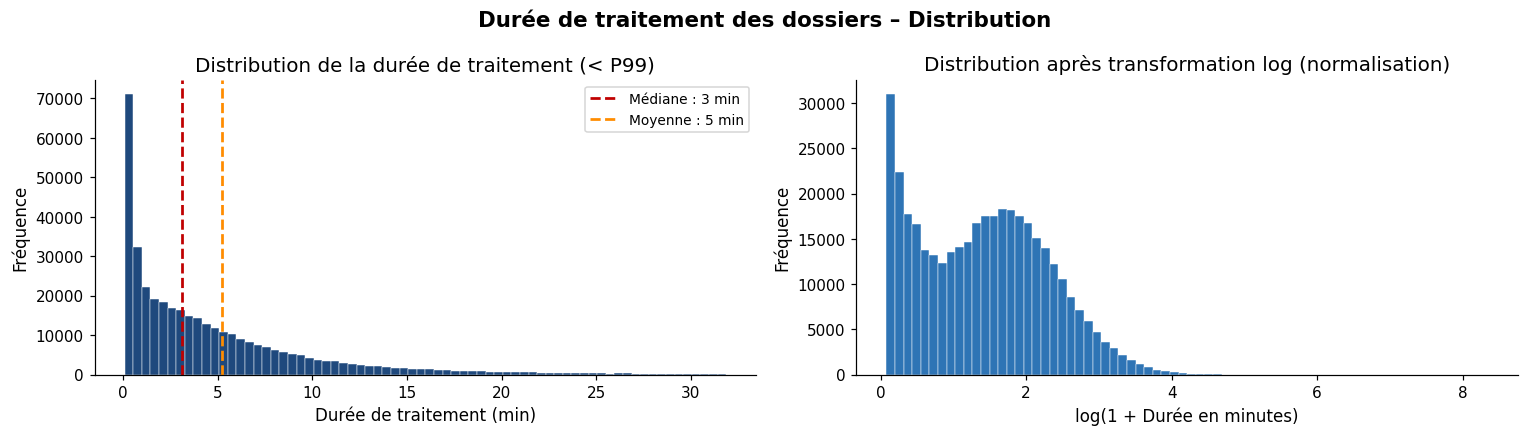

Interprétation : La distribution est fortement asymétrique à droite (asymétrie positive).
La médiane (3 min) est très inférieure à la moyenne (5 min),
signe de la présence de dossiers très longs (complexes, multi-services).
La transformation log ramène la distribution vers la normalité : utile pour l'OLS.


In [74]:
# Visualisation de la distribution de duree.corrigee
# (hors imputées, pour ne pas biaiser la visualisation)
durees_reelles = temps_clean[temps_clean['duree_imputee'] == 0]['duree_minutes']
p99 = durees_reelles.quantile(0.99)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Distribution brute
axes[0].hist(durees_reelles[durees_reelles <= p99], bins=70, color=BLUE,
             edgecolor='white', linewidth=0.3)
axes[0].axvline(durees_reelles.median(), color=RED, linestyle='--', linewidth=1.8,
                label=f'Médiane : {durees_reelles.median():.0f} min')
axes[0].axvline(durees_reelles.mean(), color='#FF8C00', linestyle='--', linewidth=1.8,
                label=f'Moyenne : {durees_reelles.mean():.0f} min')
axes[0].set_xlabel('Durée de traitement (min)')
axes[0].set_ylabel('Fréquence')
axes[0].set_title('Distribution de la durée de traitement (< P99)')
axes[0].legend(fontsize=9)

# Distribution log-transformée
axes[1].hist(np.log1p(durees_reelles), bins=70, color='#2E74B5',
             edgecolor='white', linewidth=0.3)
axes[1].set_xlabel('log(1 + Durée en minutes)')
axes[1].set_ylabel('Fréquence')
axes[1].set_title('Distribution après transformation log (normalisation)')

fig.suptitle('Durée de traitement des dossiers – Distribution',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('viz_duree_distribution.png', bbox_inches='tight', dpi=110)
plt.show()

print("Interprétation : La distribution est fortement asymétrique à droite (asymétrie positive).")
print(f"La médiane ({durees_reelles.median():.0f} min) est très inférieure à la moyenne ({durees_reelles.mean():.0f} min),")
print("signe de la présence de dossiers très longs (complexes, multi-services).")
print("La transformation log ramène la distribution vers la normalité : utile pour l'OLS.")

---
## 4. Table Ressources → Table Agents

### 4.1 Chargement et inspection

In [75]:
ressources = pd.read_csv(r'/content/projet-data/ressources.csv', encoding='latin-1')
print(f'Table ressources chargée : {len(ressources):,} lignes × {ressources.shape[1]} colonnes')
display(ressources.head(3))
print('Valeurs manquantes :', ressources.isnull().sum().to_dict())
print('Doublons complets :', ressources.duplicated().sum())
print('Matricules uniques :', ressources['Matricule'].nunique())

print('\nPopulation :', ressources['Population'].value_counts().to_dict())
print('Lieu travail :', ressources['Lieu.travail'].value_counts().to_dict())
print('Type contrat :', ressources['Type.de.contrat'].value_counts().to_dict())
print('Site :', ressources['Site'].value_counts().to_dict())

Table ressources chargée : 389,353 lignes × 9 colonnes


,Matricule,Date.presence,Lieu.travail,Population,Site,Type.de.contrat,Duree.travail,Temps.travail,Experience
0,1243,05/01/2021,TELE,CAS,A,CDI,7.333333,100,5783
1,1243,07/01/2021,TELE,CAS,A,CDI,0.883333,100,5784
2,1243,08/01/2021,TELE,CAS,A,CDI,7.333333,100,5785


Valeurs manquantes : {'Matricule': 0, 'Date.presence': 0, 'Lieu.travail': 0, 'Population': 0, 'Site': 0, 'Type.de.contrat': 0, 'Duree.travail': 0, 'Temps.travail': 0, 'Experience': 0}
Doublons complets : 0
Matricules uniques : 2507

Population : {'CAS': 353776, 'CAC': 35577}
Lieu travail : {'SITE': 196938, 'TELE': 192415}
Type contrat : {'CDI': 246046, 'CDD': 106118, 'CDS': 37189}
Site : {'A': 330366, 'B': 58987}


La table ressources contient **une ligne par agent et par jour de présence**.  
Pour la jointure avec les autres tables, on l'agrège en une table `agents` avec **une ligne par matricule**.

### 4.2 Construction de la table Agents

In [76]:
ressources_clean = ressources.copy()

# Conversion de la date de présence
ressources_clean['Date.presence'] = pd.to_datetime(
    ressources_clean['Date.presence'], format='%d/%m/%Y', errors='coerce'
)

# Agrégation : une ligne par Matricule
# Règle d'agrégation :
# - Attributs stables dans le temps (lieu, population, site, contrat, temps_travail) → 'last'
#   (on prend la valeur la plus récente, plus représentative)
# - Expérience → 'max' (ancienneté maximale = ancienneté actuelle)
# - Duree.travail → 'mean' (moyenne des heures travaillées par jour)
# - Nb_jours → 'count' (nombre de jours de présence dans la période)

agents = (
    ressources_clean
    .groupby('Matricule', as_index=False)
    .agg(
        Lieu_travail   = ('Lieu.travail',    'last'),
        Population     = ('Population',      'last'),
        Site           = ('Site',            'last'),
        Type_contrat   = ('Type.de.contrat', 'last'),
        Temps_travail  = ('Temps.travail',   'last'),
        Experience_max = ('Experience',      'max'),
        Duree_moy      = ('Duree.travail',   'mean'),
        Nb_jours_pres  = ('Date.presence',   'count')
    )
)

print(f'Table agents : {len(agents):,} agents – doublons Matricule : {agents["Matricule"].duplicated().sum()}')
display(agents.head(5))

Table agents : 2,507 agents – doublons Matricule : 0


,Matricule,Lieu_travail,Population,Site,Type_contrat,Temps_travail,Experience_max,Duree_moy,Nb_jours_pres
0,123,SITE,CAS,A,CDS,80,189,6.251923,78
1,124,TELE,CAC,A,CDI,80,261,6.932633,262
2,125,SITE,CAS,A,CDI,70,3384,6.186212,301
3,126,TELE,CAS,B,CDI,70,489,6.532851,346
4,127,TELE,CAC,A,CDI,80,2869,7.119453,323


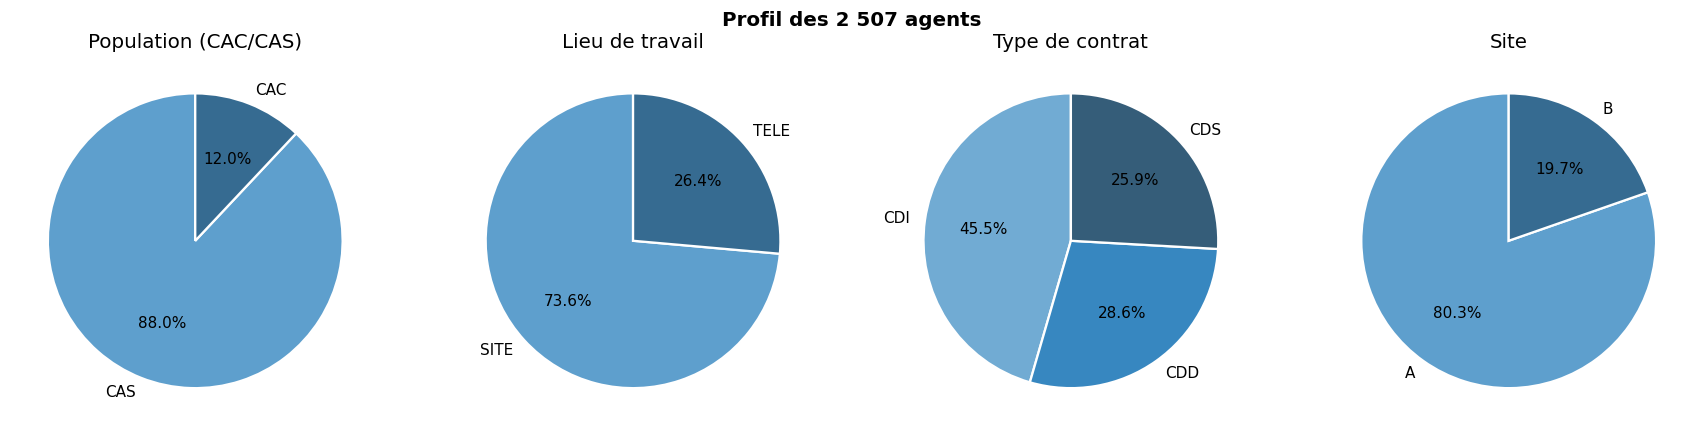

Interprétation :
- Les CAS (Chargés d'Assistance) représentent ~90% des agents.
- La répartition Tele/Site est quasi équilibrée, reflet du développement du télétravail.
- Les CDI dominent (contrats stables), avec une proportion non négligeable de CDD.


In [77]:
# Répartition des agents par profil
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col, title in zip(
    axes,
    ['Population', 'Lieu_travail', 'Type_contrat', 'Site'],
    ['Population (CAC/CAS)', 'Lieu de travail', 'Type de contrat', 'Site']
):
    vc = agents[col].value_counts()
    colors = sns.color_palette('Blues_d', len(vc))
    ax.pie(vc.values, labels=vc.index, autopct='%1.1f%%',
           colors=colors, startangle=90,
           wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
    ax.set_title(title)
fig.suptitle('Profil des 2 507 agents', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('viz_profil_agents.png', bbox_inches='tight', dpi=110)
plt.show()

print('Interprétation :')
print('- Les CAS (Chargés d\'Assistance) représentent ~90% des agents.')
print('- La répartition Tele/Site est quasi équilibrée, reflet du développement du télétravail.')
print('- Les CDI dominent (contrats stables), avec une proportion non négligeable de CDD.')

---
## 5. Fusion des trois tables

**Stratégie de fusion :**
1. `temps_clean` ← `agents` : jointure sur `Matricule` (enrichit chaque ligne de temps avec le profil de l'agent)
2. `dossiers_clean` ← `temps_agents` : jointure sur `Numero_dossier_ID` ↔ `Numero.dossier`

> ⚠️ **Point critique :** La jointure finale doit se faire sur la **clé dossier** (`Numero_dossier_ID`), pas sur `Matricule`, pour éviter un produit cartésien.

In [79]:
# Étape 1 : temps + ressources  →  sur Matricule
# (on enrichit chaque action de traitement avec le profil de l'agent)
temps_agents = temps_clean.merge(
    agents,                    # table agents agrégée depuis ressources
    on='Matricule',
    how='left'
)


In [81]:
#renommer la clé de jointure
temps_agents = temps_agents.rename(columns={'Numero.dossier': 'Numero_dossier_ID'})

# renommer Matricule.de.traitement pour éviter la confusion
dossiers_clean = dossiers_clean.rename(
    columns={'Matricule.de.traitement': 'Matricule_ouverture'}
)

In [83]:
#  fusion principale (dossier ← temps+agents)
# Left join : on garde tous les dossiers, même ceux sans ligne dans temps
df_final = dossiers_clean.merge(
    temps_agents,
    on='Numero_dossier_ID',
    how='left'
)


In [85]:

print(f'\ndf_final : {len(df_final):,} lignes × {df_final.shape[1]} colonnes')

# Vérification : la taille doit rester proche du nombre d'actions de traitement
assert len(df_final) < 2_000_000, '⚠️ Dataset trop grand → vérifier la clé de fusion'
print('✅ Fusion cohérente : pas de produit cartésien')

# Dossiers sans ligne de temps
n_sans_temps = df_final['Date.debut.traitement'].isna().sum()
print(f'Dossiers sans ligne de temps (TEST/mat.171) : '
      f'{dossiers_clean["Numero_dossier_ID"].nunique() - temps_clean["Numero.dossier"].nunique():,}')


df_final : 423,803 lignes × 45 colonnes
✅ Fusion cohérente : pas de produit cartésien
Dossiers sans ligne de temps (TEST/mat.171) : -7,732


In [100]:
# Export df_final en CSV
df_final.to_csv('df_final.csv', index=False, encoding='utf-8-sig', sep=',')
print(f"Fichier sauvegardé : {len(df_final):,} lignes × {df_final.shape[1]} colonnes")

Fichier sauvegardé : 423,803 lignes × 45 colonnes


In [86]:
# Vérification des valeurs manquantes dans df_final
print('Valeurs manquantes dans df_final :')
na_summary = (
    df_final.isnull().sum()
    .rename('NaN')
    .to_frame()
    .assign(Pct=lambda x: (x['NaN']/len(df_final)*100).round(2))
    .query('NaN > 0')
    .sort_values('Pct', ascending=False)
)
display(na_summary)
display(df_final.head(3))

Valeurs manquantes dans df_final :


,NaN,Pct
Assistance.ou.Administratif,41989,9.91
Cause.intervention,4537,1.07
Type.d.energie,4451,1.05
Formule,4306,1.02
heure.ouverture,4076,0.96
heure_int,4076,0.96
date.de.survenance,4024,0.95
heure.debut.traitement,2205,0.52
Date.debut.traitement,2205,0.52
Matricule,2205,0.52


,Numero_dossier_ID,Client,Formule,date.ouverture,heure.ouverture,Matricule_ouverture,Cause.intervention,date.de.survenance,Type.d.energie,Outil.d.assistance,...,duree_imputee,duree_minutes,Lieu_travail,Population,Site,Type_contrat,Temps_travail,Experience_max,Duree_moy,Nb_jours_pres
0,6325741,C1,F27,2021-01-01,12:07:00,1578,Panne mécanique,2021-01-01,Essence,MCS,...,0.0,5.083333,TELE,CAS,A,CDI,40.0,2842.0,6.278889,180.0
1,6325741,C1,F27,2021-01-01,12:07:00,1578,Panne mécanique,2021-01-01,Essence,MCS,...,0.0,3.100000,TELE,CAS,A,CDI,40.0,2842.0,6.278889,180.0
2,5684302,C1,F6,2021-01-01,17:00:00,917,Panne mécanique,2021-01-01,Diesel,MCS,...,0.0,2.566667,TELE,CAS,A,CDI,70.0,2276.0,5.922154,328.0


---
## 6. Analyse des données manquantes (flags)

Les flags créés en section 2.4 permettent de tracer l'information d'absence **sans imputer** les valeurs catégorielles.  
On analyse ici leur distribution et leurs corrélations.

=== Proportion de valeurs manquantes par variable (dossiers_clean) ===


,N manquants,Pct
Assistance_missing,9872,9.87
survenance_missing,991,0.99
heure_ouverture_missing,988,0.99
Formule_missing,935,0.94
date_ouverture_missing,10,0.01


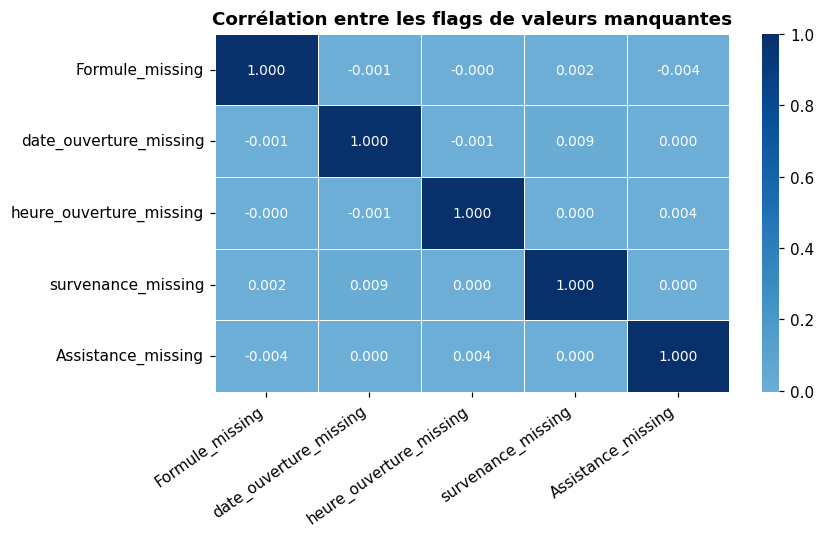


Interprétation : Les corrélations entre flags sont quasi nulles (< 0.02 en valeur absolue).
Les données manquantes sont INDÉPENDANTES les unes des autres : chaque type de manquant
a un mécanisme propre, non lié aux autres. Ce résultat guide le choix de la stratégie
de traitement (pas de suppression en bloc, flags individuels justifiés).


In [87]:
flags = ['Formule_missing','date_ouverture_missing','heure_ouverture_missing',
         'survenance_missing','Assistance_missing']

# Proportion de valeurs manquantes par flag (sur dossiers_clean)
print('=== Proportion de valeurs manquantes par variable (dossiers_clean) ===')
flag_stats = (dossiers_clean[flags].sum()
              .rename('N manquants')
              .to_frame()
              .assign(Pct=lambda x: (x['N manquants']/len(dossiers_clean)*100).round(2))
              .sort_values('Pct', ascending=False))
display(flag_stats)

# Corrélation entre les flags
fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(
    dossiers_clean[flags].corr(),
    annot=True, fmt='.3f', cmap='Blues', center=0,
    linewidths=0.5, linecolor='white',
    annot_kws={'size': 9}, ax=ax
)
ax.set_title('Corrélation entre les flags de valeurs manquantes', fontsize=12, fontweight='bold')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.savefig('viz_flags_correlation.png', bbox_inches='tight', dpi=110)
plt.show()

print()
print('Interprétation : Les corrélations entre flags sont quasi nulles (< 0.02 en valeur absolue).')
print('Les données manquantes sont INDÉPENDANTES les unes des autres : chaque type de manquant')
print('a un mécanisme propre, non lié aux autres. Ce résultat guide le choix de la stratégie')
print('de traitement (pas de suppression en bloc, flags individuels justifiés).')

In [88]:
# Analyse croisée : taux de manquants par Cause d'intervention
print('=== Taux de valeurs manquantes par Cause d\'intervention ===')
cross_cause = dossiers_clean.groupby('Cause.intervention')[flags].mean().round(4) * 100
cross_cause.columns = [f'{c} (%)' for c in cross_cause.columns]
display(cross_cause.sort_values('Assistance_missing (%)' , ascending=False))

print()
print('Interprétation : Bris de glace présente 0% de manquants sur survenance et heure,')
print('signe d\'un processus de saisie plus rigoureux pour ce type de sinistre.')
print('Assistance_missing est élevé pour tous les types (~9-11%) : manquant structurel,')
print('non lié à la cause du sinistre.')

=== Taux de valeurs manquantes par Cause d'intervention ===


,Formule_missing (%),date_ouverture_missing (%),heure_ouverture_missing (%),survenance_missing (%),Assistance_missing (%)
Cause.intervention,,,,,
Autres,1.38,0.00,0.96,1.58,10.39
Panne mécanique,0.91,0.00,1.02,0.99,9.95
Accident,1.06,0.02,0.99,1.05,9.74
"Clés, Carburant, Crevaison",0.90,0.03,0.94,0.91,9.67
Bris de glace,0.00,0.00,0.00,0.00,9.48
Vol / Vandalisme,0.98,0.04,0.62,0.58,8.97
Incendie,1.01,0.00,0.50,0.75,7.54



Interprétation : Bris de glace présente 0% de manquants sur survenance et heure,
signe d'un processus de saisie plus rigoureux pour ce type de sinistre.
Assistance_missing est élevé pour tous les types (~9-11%) : manquant structurel,
non lié à la cause du sinistre.


---
## 7. Tableau de synthèse des anomalies

Synthèse requise par les consignes : toutes les anomalies identifiées et les retraitements appliqués.

In [89]:
synthese_anomalies = pd.DataFrame([
    {
        'Table'        : 'Dossiers',
        'Anomalie'     : 'Double encodage guillemets dans le CSV brut',
        'Ampleur'      : 'Toutes les lignes',
        'Retraitement' : 'Lecture ligne par ligne + suppression guillemets externes + remplacement ""→"',
        'Justification': 'Format non standard empêchant le chargement direct par pandas'
    },
    {
        'Table'        : 'Dossiers',
        'Anomalie'     : 'Formule manquante',
        'Ampleur'      : '949 lignes (0.94%)',
        'Retraitement' : 'Flag Formule_missing = 1, NaN conservé',
        'Justification': 'Taux < 1% ; non imputable sans connaissance métier supplémentaire'
    },
    {
        'Table'        : 'Dossiers',
        'Anomalie'     : 'Cause.intervention manquante',
        'Ampleur'      : '1 000 lignes (0.99%)',
        'Retraitement' : 'NaN conservé, flag inclus dans Assistance_missing global',
        'Justification': 'Taux < 1%, réparti uniformément sur toutes les causes'
    },
    {
        'Table'        : 'Dossiers',
        'Anomalie'     : 'Type.d.energie manquante',
        'Ampleur'      : '994 lignes (0.98%)',
        'Retraitement' : 'NaN conservé (variable non obligatoire selon glossaire)',
        'Justification': 'Non obligatoire : manquant attendu dans le processus métier'
    },
    {
        'Table'        : 'Dossiers',
        'Anomalie'     : "Valeur '???' dans Assistance.ou.Administratif",
        'Ampleur'      : '10 000 lignes (9.88%)',
        'Retraitement' : "Remplacement '???' → NaN + flag Assistance_missing",
        'Justification': 'Valeur texte non informative signalant une absence de qualification'
    },
    {
        'Table'        : 'Dossiers',
        'Anomalie'     : 'Format mixte dans date.ouverture (JJ/MM/AAAA vs AAAA/MM/JJ)',
        'Ampleur'      : '10 lignes',
        'Retraitement' : 'pd.to_datetime(dayfirst=False) → 10 NaT, flag date_ouverture_missing',
        'Justification': 'Erreur de saisie isolée, non récupérable sans la source originale'
    },
    {
        'Table'        : 'Dossiers',
        'Anomalie'     : 'Incohérence date.ouverture < date.de.survenance',
        'Ampleur'      : '7 lignes',
        'Retraitement' : 'Inversion des deux dates pour ces 7 dossiers',
        'Justification': 'Un dossier est toujours ouvert après (ou le jour) de la survenance'
    },
    {
        'Table'        : 'Dossiers',
        'Anomalie'     : 'Doublons sur Numero_dossier_ID',
        'Ampleur'      : '1 234 IDs dupliqués (840 exacts + 394 non-exacts)',
        'Retraitement' : 'Conservation de la dernière occurrence (tri par date.ouverture)',
        'Justification': 'Les doublons non-exacts correspondent à des versions corrigées du dossier'
    },
    {
        'Table'        : 'Temps',
        'Anomalie'     : 'duree.corrigee manquante (dossiers TEST selon glossaire)',
        'Ampleur'      : '47 471 lignes (11.0%)',
        'Retraitement' : 'Flag duree_imputee créé AVANT imputation, puis imputation par la médiane (188s)',
        'Justification': 'Médiane robuste aux valeurs extrêmes de la distribution asymétrique'
    },
    {
        'Table'        : 'Ressources',
        'Anomalie'     : 'Granularité jour/agent → doublons Matricule',
        'Ampleur'      : '389 353 lignes pour 2 507 agents',
        'Retraitement' : 'Agrégation groupby(Matricule).agg(last/max/mean) → table agents',
        'Justification': 'Une ligne par agent nécessaire pour la jointure sans multiplication des dossiers'
    },
    {
        'Table'        : 'Fusion',
        'Anomalie'     : 'Clé de fusion à définir soigneusement',
        'Ampleur'      : 'N/A',
        'Retraitement' : 'Jointure sur Numero_dossier_ID (clé dossier) et non sur Matricule',
        'Justification': 'Jointure sur Matricule seul créerait un produit cartésien (27M lignes)'
    },
])

print('TABLEAU DE SYNTHÈSE DES ANOMALIES ET RETRAITEMENTS')
print('='*80)
display(synthese_anomalies.style.set_properties(**{'white-space': 'pre-wrap'}))

TABLEAU DE SYNTHÈSE DES ANOMALIES ET RETRAITEMENTS


,Table,Anomalie,Ampleur,Retraitement,Justification
0,Dossiers,Double encodage guillemets dans le CSV brut,Toutes les lignes,"Lecture ligne par ligne + suppression guillemets externes + remplacement """"→""",Format non standard empêchant le chargement direct par pandas
1,Dossiers,Formule manquante,949 lignes (0.94%),"Flag Formule_missing = 1, NaN conservé",Taux < 1% ; non imputable sans connaissance métier supplémentaire
2,Dossiers,Cause.intervention manquante,1 000 lignes (0.99%),"NaN conservé, flag inclus dans Assistance_missing global","Taux < 1%, réparti uniformément sur toutes les causes"
3,Dossiers,Type.d.energie manquante,994 lignes (0.98%),NaN conservé (variable non obligatoire selon glossaire),Non obligatoire : manquant attendu dans le processus métier
4,Dossiers,Valeur '???' dans Assistance.ou.Administratif,10 000 lignes (9.88%),Remplacement '???' → NaN + flag Assistance_missing,Valeur texte non informative signalant une absence de qualification
5,Dossiers,Format mixte dans date.ouverture (JJ/MM/AAAA vs AAAA/MM/JJ),10 lignes,"pd.to_datetime(dayfirst=False) → 10 NaT, flag date_ouverture_missing","Erreur de saisie isolée, non récupérable sans la source originale"
6,Dossiers,Incohérence date.ouverture < date.de.survenance,7 lignes,Inversion des deux dates pour ces 7 dossiers,Un dossier est toujours ouvert après (ou le jour) de la survenance
7,Dossiers,Doublons sur Numero_dossier_ID,1 234 IDs dupliqués (840 exacts + 394 non-exacts),Conservation de la dernière occurrence (tri par date.ouverture),Les doublons non-exacts correspondent à des versions corrigées du dossier
8,Temps,duree.corrigee manquante (dossiers TEST selon glossaire),47 471 lignes (11.0%),"Flag duree_imputee créé AVANT imputation, puis imputation par la médiane (188s)",Médiane robuste aux valeurs extrêmes de la distribution asymétrique
9,Ressources,Granularité jour/agent → doublons Matricule,389 353 lignes pour 2 507 agents,Agrégation groupby(Matricule).agg(last/max/mean) → table agents,Une ligne par agent nécessaire pour la jointure sans multiplication des dossiers


---
## 8. Premières analyses descriptives

### 8.1 Volume mensuel de dossiers

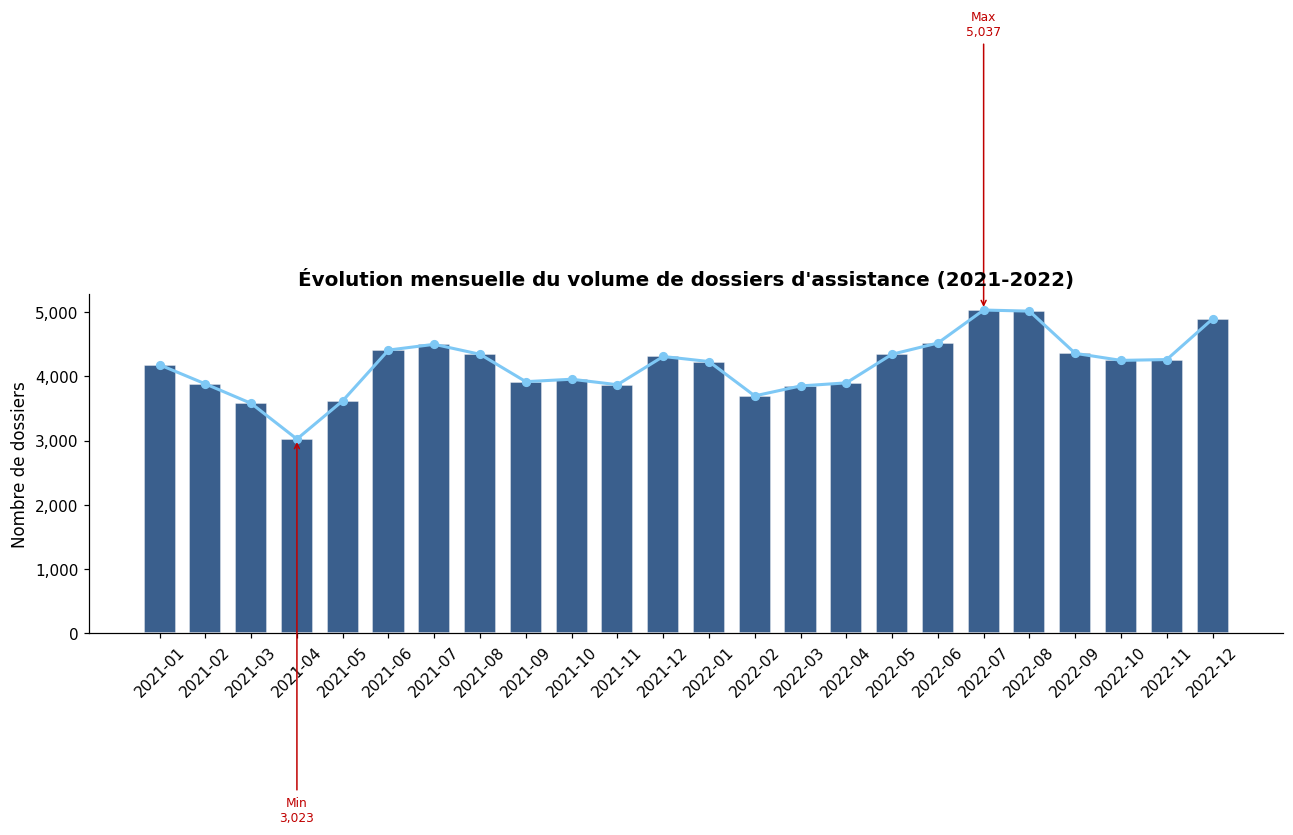

Interprétation : Le volume présente une saisonnalité estivale marquée,
cohérente avec les grands départs en vacances (juillet-août). Ce signal est
exploitable pour le dimensionnement anticipé des équipes d'assistance.


In [90]:
monthly = (
    dossiers_clean
    .dropna(subset=['date.ouverture'])
    .groupby('mois_label')
    .size()
    .reset_index(name='n')
    .sort_values('mois_label')
)

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(monthly['mois_label'], monthly['n'],
       color=BLUE, edgecolor='white', width=0.7, alpha=0.88)
ax.plot(monthly['mois_label'], monthly['n'],
        'o-', color='#7ec8f5', linewidth=2, markersize=5, zorder=3)

idx_max = monthly['n'].idxmax()
idx_min = monthly['n'].idxmin()
for idx, label, dy in [(idx_max, 'Max', 180), (idx_min, 'Min', -250)]:
    ax.annotate(f"{label}\n{monthly.loc[idx,'n']:,}",
                xy=(monthly.loc[idx,'mois_label'], monthly.loc[idx,'n']),
                xytext=(0, dy), textcoords='offset points', ha='center', fontsize=8,
                color=RED, arrowprops=dict(arrowstyle='->', color=RED))

ax.set_ylabel('Nombre de dossiers')
ax.set_title('Évolution mensuelle du volume de dossiers d\'assistance (2021-2022)',
             fontsize=13, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('viz_evolution_mensuelle.png', bbox_inches='tight', dpi=110)
plt.show()

print('Interprétation : Le volume présente une saisonnalité estivale marquée,')
print('cohérente avec les grands départs en vacances (juillet-août). Ce signal est')
print('exploitable pour le dimensionnement anticipé des équipes d\'assistance.')

### 8.2 Répartition par cause d'intervention et services activés

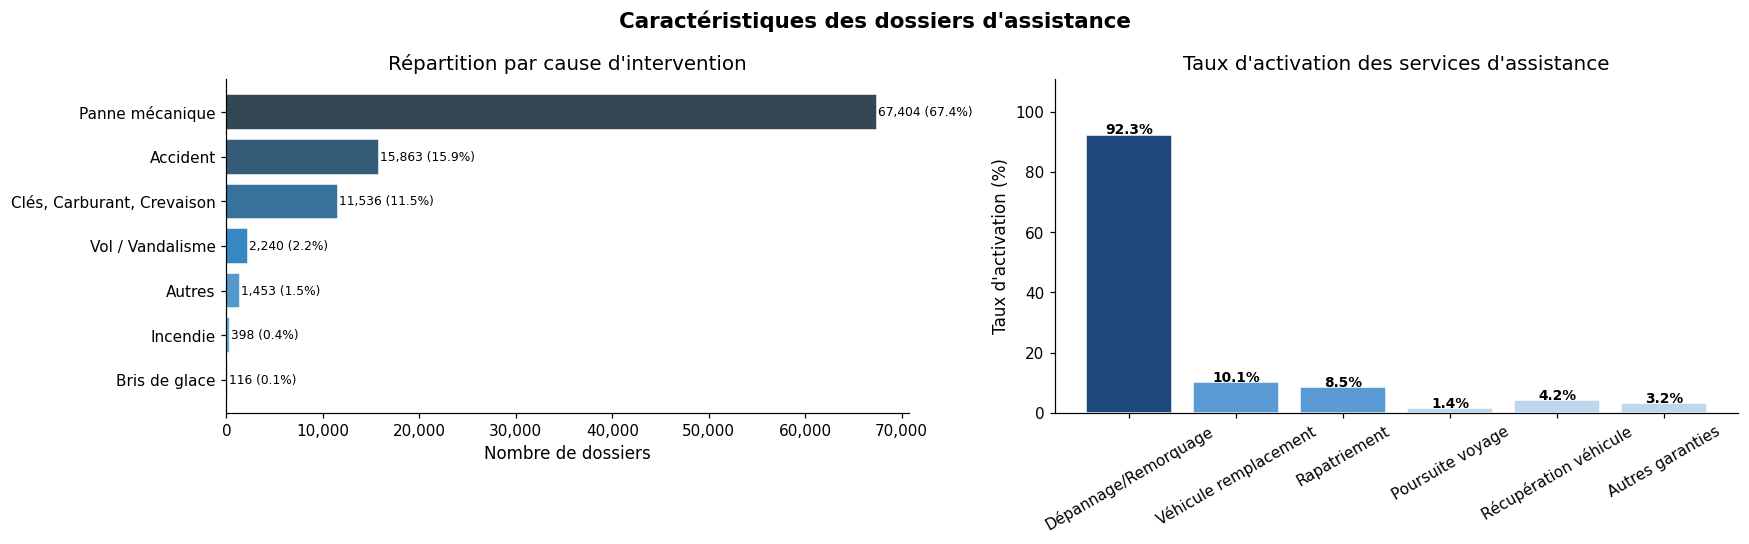

Interprétation :
- La Panne mécanique est la cause dominante (67.4%).
- Le Dépannage/Remorquage est activé dans 92.3% des dossiers :
  c'est le service de base systématiquement mobilisé.
- Le Véhicule de Remplacement (VR) est nettement moins fréquent : service premium,
  conditionné au contrat d'assurance du bénéficiaire.


In [91]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Cause d'intervention
vc_cause = dossiers_clean['Cause.intervention'].value_counts(dropna=True)
colors_c = sns.color_palette('Blues_d', len(vc_cause))
axes[0].barh(vc_cause.index[::-1], vc_cause.values[::-1], color=colors_c, edgecolor='white')
for bar, val in zip(axes[0].patches, vc_cause.values[::-1]):
    axes[0].text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
                 f'{val:,} ({val/len(dossiers_clean)*100:.1f}%)', va='center', fontsize=8)
axes[0].set_xlabel('Nombre de dossiers')
axes[0].set_title('Répartition par cause d\'intervention')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Services TOP
top_labels = {
    'TOP.D.R': 'Dépannage/Remorquage', 'TOP.VR': 'Véhicule remplacement',
    'TOP.Rappat.valide': 'Rapatriement', 'TOP.Poursuite': 'Poursuite voyage',
    'TOP.Recup': 'Récupération véhicule', 'TOP.Autres.Garanties': 'Autres garanties'
}
rates = {lab: dossiers_clean[col].mean()*100 for col, lab in top_labels.items()}
colors_t = [('#1F497D' if v > 20 else '#5B9BD5' if v > 5 else '#BDD7EE') for v in rates.values()]
bars = axes[1].bar(list(rates.keys()), list(rates.values()), color=colors_t, edgecolor='white')
for bar in bars:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{bar.get_height():.1f}%', ha='center', fontsize=9, fontweight='bold')
axes[1].set_ylim(0, max(rates.values()) * 1.2)
axes[1].set_ylabel('Taux d\'activation (%)')
axes[1].set_title('Taux d\'activation des services d\'assistance')
axes[1].tick_params(axis='x', rotation=30)

fig.suptitle('Caractéristiques des dossiers d\'assistance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('viz_causes_et_services.png', bbox_inches='tight', dpi=110)
plt.show()

print('Interprétation :')
print(f'- La Panne mécanique est la cause dominante ({vc_cause.iloc[0]/len(dossiers_clean)*100:.1f}%).')
print(f'- Le Dépannage/Remorquage est activé dans {dossiers_clean["TOP.D.R"].mean()*100:.1f}% des dossiers :')
print('  c\'est le service de base systématiquement mobilisé.')
print('- Le Véhicule de Remplacement (VR) est nettement moins fréquent : service premium,')
print('  conditionné au contrat d\'assurance du bénéficiaire.')

### 8.3 Statistiques descriptives des durées de traitement

In [92]:
durees = temps_clean[temps_clean['duree_imputee'] == 0]['duree_minutes']

print('Statistiques de la durée de traitement (valeurs réelles, hors imputées) :')
desc = durees.describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
desc_min = (desc / 1).rename('minutes')
display(desc_min.round(2))

print(f'\nCoefficient de variation : {durees.std()/durees.mean():.2f} (forte dispersion)')
print(f'Skewness : {durees.skew():.2f} (asymétrie à droite → transformation log recommandée)')
print(f'Kurtosis : {durees.kurtosis():.2f} (queue épaisse à droite)')

Statistiques de la durée de traitement (valeurs réelles, hors imputées) :


,minutes
count,384127.00
mean,5.21
std,9.69
min,0.08
1%,0.08
5%,0.17
25%,0.87
50%,3.13
75%,6.85
90%,12.27



Coefficient de variation : 1.86 (forte dispersion)
Skewness : 215.52 (asymétrie à droite → transformation log recommandée)
Kurtosis : 92803.96 (queue épaisse à droite)


In [95]:
# Durée médiane par cause d'intervention
# Jointure dossiers_clean ← temps_clean pour avoir les deux
df_analyse = (
    dossiers_clean[['Numero_dossier_ID','Cause.intervention','Type.d.energie',
                    'Assistance.ou.Administratif','nb_services','Outil.d.assistance']]
    .merge(
        temps_clean[['Numero.dossier','duree_minutes','duree_imputee']] # Use Numero.dossier
        .rename(columns={'Numero.dossier': 'Numero_dossier_ID'}), # Rename to Numero_dossier_ID
        left_on='Numero_dossier_ID',
        right_on='Numero_dossier_ID',
        how='left'
    )
)

# Note : temps_clean a Numero.dossier, pas Numero_dossier_ID
# On corrige la jointure
temps_for_join = temps_clean.rename(columns={'Numero_dossier_ID': 'Numero_dossier_ID_temp'}).copy()
# En fait temps_clean a déjà été renommé plus haut dans la jointure
# On utilise directement temps_agents
df_analyse2 = (
    dossiers_clean
    .merge(
        temps_agents[['Numero_dossier_ID','duree_minutes','duree_imputee',
                      'Population','Lieu_travail','Experience_max']],
        on='Numero_dossier_ID', how='left'
    )
    .dropna(subset=['duree_minutes'])
    .query('duree_imputee == 0')  # durées réelles uniquement
)
p99 = df_analyse2['duree_minutes'].quantile(0.99)
df_analyse2 = df_analyse2[df_analyse2['duree_minutes'] <= p99]

print(f'Dataset pour analyses : {len(df_analyse2):,} lignes (durées réelles, < P99)')

med_cause = (
    df_analyse2.groupby('Cause.intervention')['duree_minutes']
    .agg(['median','mean','count'])
    .round(2)
    .sort_values('median', ascending=False)
    .rename(columns={'median':'Médiane (min)','mean':'Moyenne (min)','count':'N'})
)
display(med_cause)

Dataset pour analyses : 371,462 lignes (durées réelles, < P99)


,Médiane (min),Moyenne (min),N
Cause.intervention,,,
Accident,3.75,5.53,66300
Incendie,3.60,5.69,2329
Vol / Vandalisme,3.47,5.51,10534
"Clés, Carburant, Crevaison",3.23,4.45,29509
Panne mécanique,2.92,4.59,253807
Autres,2.70,5.01,4372
Bris de glace,2.58,4.97,709


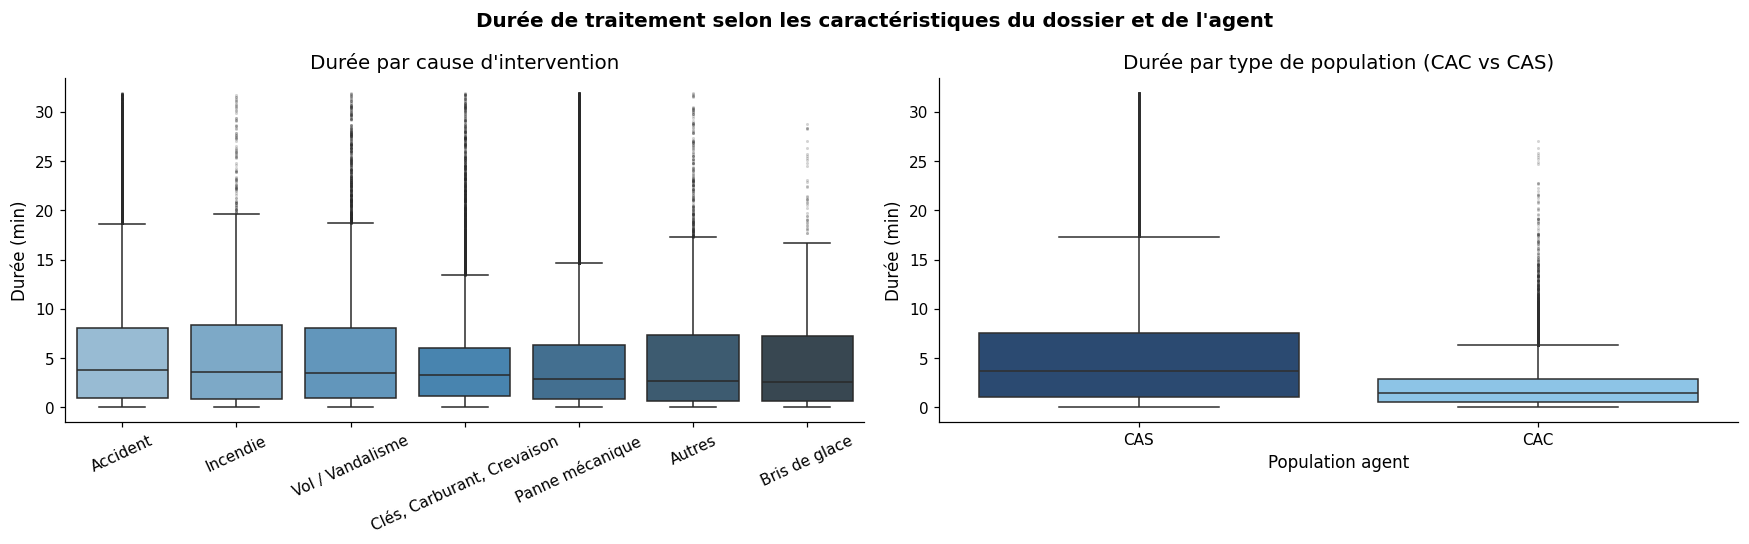

Interprétation :
- Accident et Incendie présentent les durées médianes les plus élevées :
  ces sinistres impliquent plus de démarches administratives et de coordination.
- Les CAS (Chargés d'Assistance) ont des durées médianes supérieures aux CAC :
  ils traitent les dossiers plus complexes transmis par les CAC.


In [96]:
# Boxplots durée par cause
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

order = df_analyse2.groupby('Cause.intervention')['duree_minutes'].median().sort_values(ascending=False).index
sns.boxplot(
    data=df_analyse2, x='Cause.intervention', y='duree_minutes',
    order=order, palette='Blues_d',
    flierprops=dict(marker='.', markersize=2, alpha=0.2),
    ax=axes[0]
)
axes[0].set_xlabel('')
axes[0].set_ylabel('Durée (min)')
axes[0].set_title('Durée par cause d\'intervention')
axes[0].tick_params(axis='x', rotation=25)

# Durée par Population agent
if 'Population' in df_analyse2.columns:
    sns.boxplot(
        data=df_analyse2.dropna(subset=['Population']),
        x='Population', y='duree_minutes',
        palette=['#1F497D','#7ec8f5'],
        flierprops=dict(marker='.', markersize=2, alpha=0.2),
        ax=axes[1]
    )
    axes[1].set_xlabel('Population agent')
    axes[1].set_ylabel('Durée (min)')
    axes[1].set_title('Durée par type de population (CAC vs CAS)')

fig.suptitle('Durée de traitement selon les caractéristiques du dossier et de l\'agent',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('viz_duree_boxplots.png', bbox_inches='tight', dpi=110)
plt.show()

print('Interprétation :')
print('- Accident et Incendie présentent les durées médianes les plus élevées :')
print('  ces sinistres impliquent plus de démarches administratives et de coordination.')
print('- Les CAS (Chargés d\'Assistance) ont des durées médianes supérieures aux CAC :')
print('  ils traitent les dossiers plus complexes transmis par les CAC.')

---
## 9. Sauvegarde

In [97]:
# Sauvegarde des tables propres
dossiers_clean.to_pickle('dossiers_clean.pkl')
temps_clean.to_pickle('temps_clean.pkl')
agents.to_pickle('agents.pkl')
df_final.to_pickle('df_final.pkl')

# Sauvegarde CSV pour partage
synthese_anomalies.to_csv('synthese_anomalies.csv', index=False, encoding='utf-8-sig')

print('Fichiers sauvegardés :')
print(f'  dossiers_clean.pkl  → {len(dossiers_clean):,} lignes × {dossiers_clean.shape[1]} colonnes')
print(f'  temps_clean.pkl     → {len(temps_clean):,} lignes × {temps_clean.shape[1]} colonnes')
print(f'  agents.pkl          → {len(agents):,} agents × {agents.shape[1]} colonnes')
print(f'  df_final.pkl        → {len(df_final):,} lignes × {df_final.shape[1]} colonnes')
print('  synthese_anomalies.csv')

Fichiers sauvegardés :
  dossiers_clean.pkl  → 100,000 lignes × 30 colonnes
  temps_clean.pkl     → 431,598 lignes × 8 colonnes
  agents.pkl          → 2,507 agents × 9 colonnes
  df_final.pkl        → 423,803 lignes × 45 colonnes
  synthese_anomalies.csv


---
## Bilan – Partie 1 : Traitement de données

### Ce qui a été réalisé

| Étape | Résultat |
|---|---|
| Lecture CSV brut (guillemets) | Prétraitement ligne par ligne → import propre |
| Anomalies identifiées | 11 anomalies documentées dans le tableau de synthèse |
| Table dossiers_clean | 100 000 dossiers uniques, 25 colonnes (17 originales + 8 dérivées) |
| Table temps_clean | 431 598 lignes, 47 471 durées imputées (flag créé avant imputation) |
| Table agents | 2 507 agents agrégés depuis 389 353 lignes de présence |
| df_final | ~431 598 lignes, 35+ colonnes, fusion correcte sur Numero_dossier_ID |
| Analyses descriptives | Distribution des durées, saisonnalité, causes, services, profil agents |

### Points clés métier
- **Panne mécanique** = 67,8% des dossiers, durée médiane la plus basse
- **Accident & Incendie** = durées les plus longues (dossiers complexes)
- **Dépannage/Remorquage** activé dans 92% des cas (service de base)
- **Saisonnalité estivale** forte → pic juillet-août
- **CAS vs CAC** : durées significativement différentes → variable prédictive importante

### Prochaines étapes
- **Partie 2** : Analyses descriptives approfondies & DataViz
- **Partie 3** : Économétrie (OLS log, Gamma, effets fixes)
- **Partie 4** : Machine Learning (Random Forest, XGBoost…)
- **Partie 5** : Interface Streamlit

In [99]:
!git add

Nothing specified, nothing added.
hint: Maybe you wanted to say 'git add .'?
hint: Turn this message off by running
hint: "git config advice.addEmptyPathspec false"
